In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
X = df.select_dtypes(include = ["float64"])
print(X)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

In [9]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

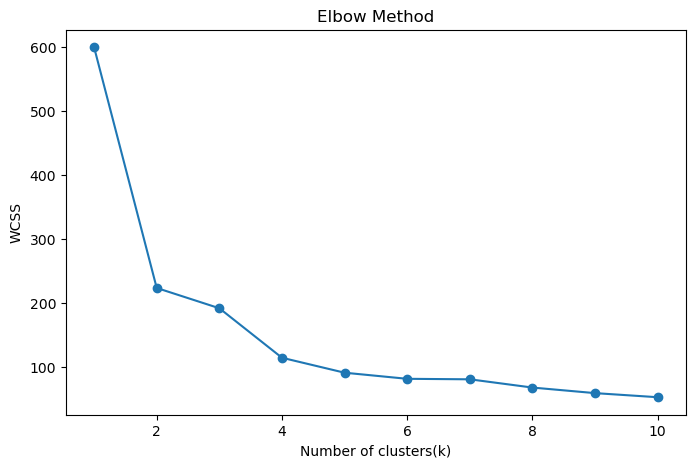

In [10]:
    
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters(k)")
plt.ylabel("WCSS")
plt.show()


In [11]:
kmeans = KMeans(n_clusters = 3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels
df.head()

C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,2
2,3,4.7,3.2,1.3,0.2,Iris-setosa,2
3,4,4.6,3.1,1.5,0.2,Iris-setosa,2
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1


In [13]:
df.tail(15)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
135,136,7.7,3.0,6.1,2.3,Iris-virginica,0
136,137,6.3,3.4,5.6,2.4,Iris-virginica,0
137,138,6.4,3.1,5.5,1.8,Iris-virginica,0
138,139,6.0,3.0,4.8,1.8,Iris-virginica,0
139,140,6.9,3.1,5.4,2.1,Iris-virginica,0
140,141,6.7,3.1,5.6,2.4,Iris-virginica,0
141,142,6.9,3.1,5.1,2.3,Iris-virginica,0
142,143,5.8,2.7,5.1,1.9,Iris-virginica,0
143,144,6.8,3.2,5.9,2.3,Iris-virginica,0
144,145,6.7,3.3,5.7,2.5,Iris-virginica,0


C:\Users\vivek\anaconda4\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vivek\anaconda4\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\vivek\anaconda4\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\vivek\anaconda4\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

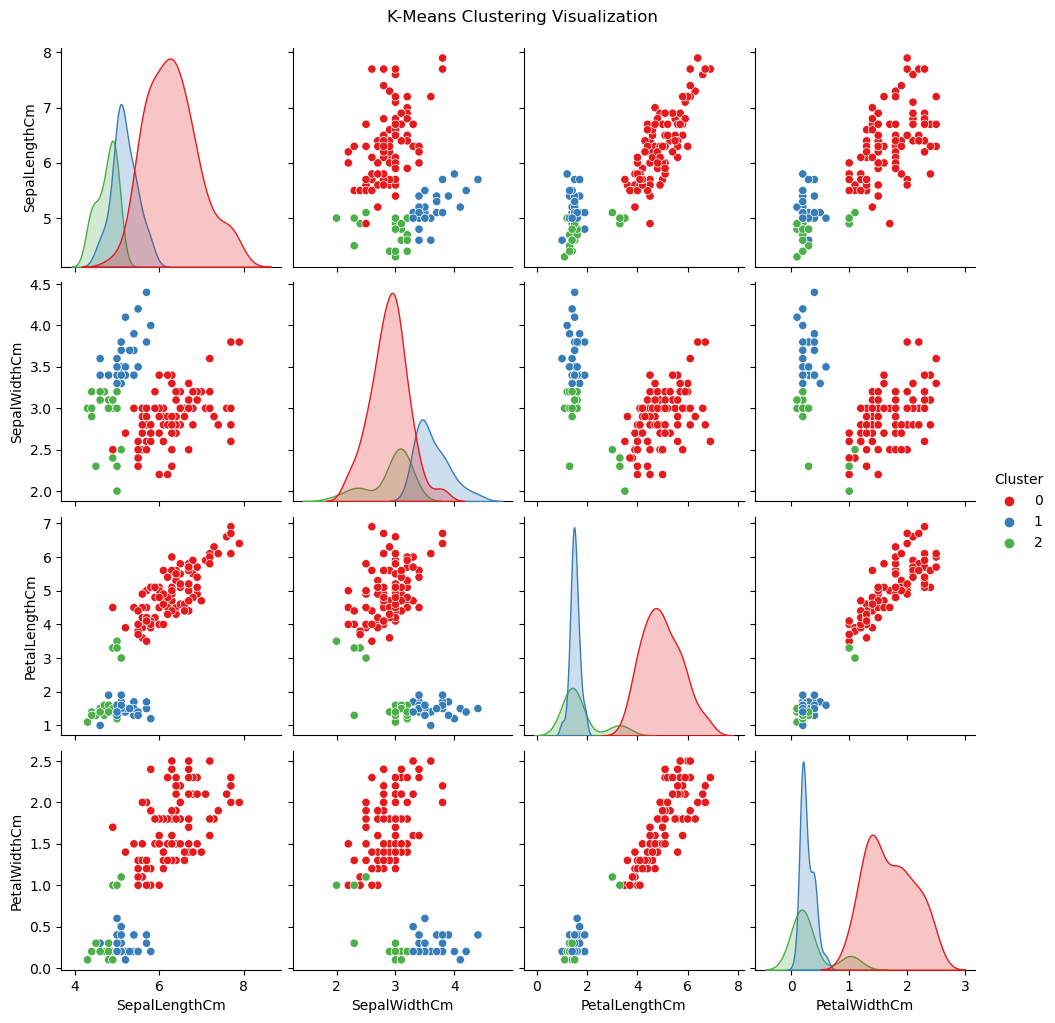

In [16]:
sns.pairplot(df, vars=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
             hue='Cluster', palette='Set1', diag_kind='kde')
plt.suptitle("K-Means Clustering Visualization", y=1.02)
plt.show()


In [14]:
from sklearn.metrics import silhouette_score
#Evaluate clustering using Silhouette Score
sil_score = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score for k=3:", sil_score)


Silhouette Score for k=3: 0.4787241921049546


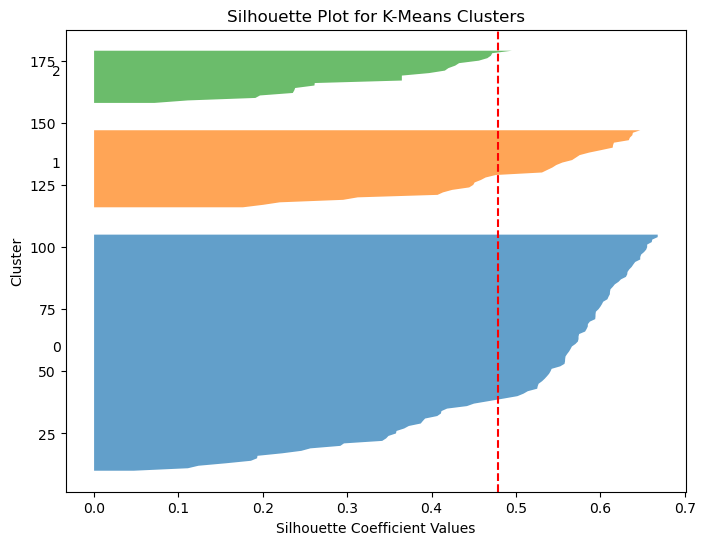

In [15]:
from sklearn.metrics import silhouette_samples
import numpy as np

#Silhouette Analysis
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

y_lower = 10
plt.figure(figsize=(8,6))

for i in range(3):  # for each cluster
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      alpha=0.7)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster")
plt.title("Silhouette Plot for K-Means Clusters")
plt.axvline(x=sil_score, color="red", linestyle="--")
plt.show()


In [17]:
# Step 11: Compare K-Means clusters with actual species
ct = pd.crosstab(df['Cluster'], df['Species'])
print(ct)


Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               46              50
1                 32                0               0
2                 18                4               0


In [26]:
# New data points (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm)
new_samples = pd.DataFrame({
    'SepalLengthCm': [5.1, 6.0, 4.8],
    'SepalWidthCm':  [3.5, 2.9, 3.0],
    'PetalLengthCm': [1.4, 5.0, 1.4],
    'PetalWidthCm':  [0.2, 1.5, 0.3]
})

# Scale new points using the existing scaler
new_samples_scaled = scaler.transform(new_samples)
# Predict cluster for new points
predicted_clusters = kmeans.predict(new_samples_scaled)
print("Predicted clusters for new samples:", predicted_clusters)


Predicted clusters for new samples: [1 0 2]


In [27]:

cluster_to_species = {
    0: 'Iris-versicolor/Iris-virginica',  
    1: 'Iris-setosa',                     
    2: 'Iris-setosa'                      
}

# Map predicted clusters to species
predicted_species = [cluster_to_species[c] for c in predicted_clusters]
print("Predicted species for new samples:", predicted_species)


Predicted species for new samples: ['Iris-setosa', 'Iris-versicolor/Iris-virginica', 'Iris-setosa']
